In [57]:
import json
import os

import pandas as pd

dir = '../data/results/experiments/new_beam_matching_experiment_4'

data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df['n_best_pcis'] = data_df['n_best_pcis'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')
data_df['n_best_beams'] = data_df['n_best_beams'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')

data_df

,errors,complexity,run,n_best_pcis,n_best_beams
0,27.329570,5431065.0,0.0,1,all
1,10.938926,5431065.0,0.0,1,all
2,13.223492,5431065.0,0.0,1,all
3,19.039902,5431065.0,0.0,1,all
4,13.771956,5431065.0,0.0,1,all
...,...,...,...,...,...
721577,0.583402,5441520.0,9.0,19,all
721578,0.582209,5441520.0,9.0,19,all
721579,0.330775,5441520.0,9.0,19,all
721580,0.205596,5441520.0,9.0,19,all


In [40]:
res = []
for group, data in data_df.groupby(['n_best_pcis', 'n_best_beams']):
    errors = data.groupby('run')['errors'].mean().values
for e in errors:
    res.append((group[0], group[1], e))

df = pd.DataFrame(res, columns=['n_best_pcis', 'n_best_beams', 'errors'])

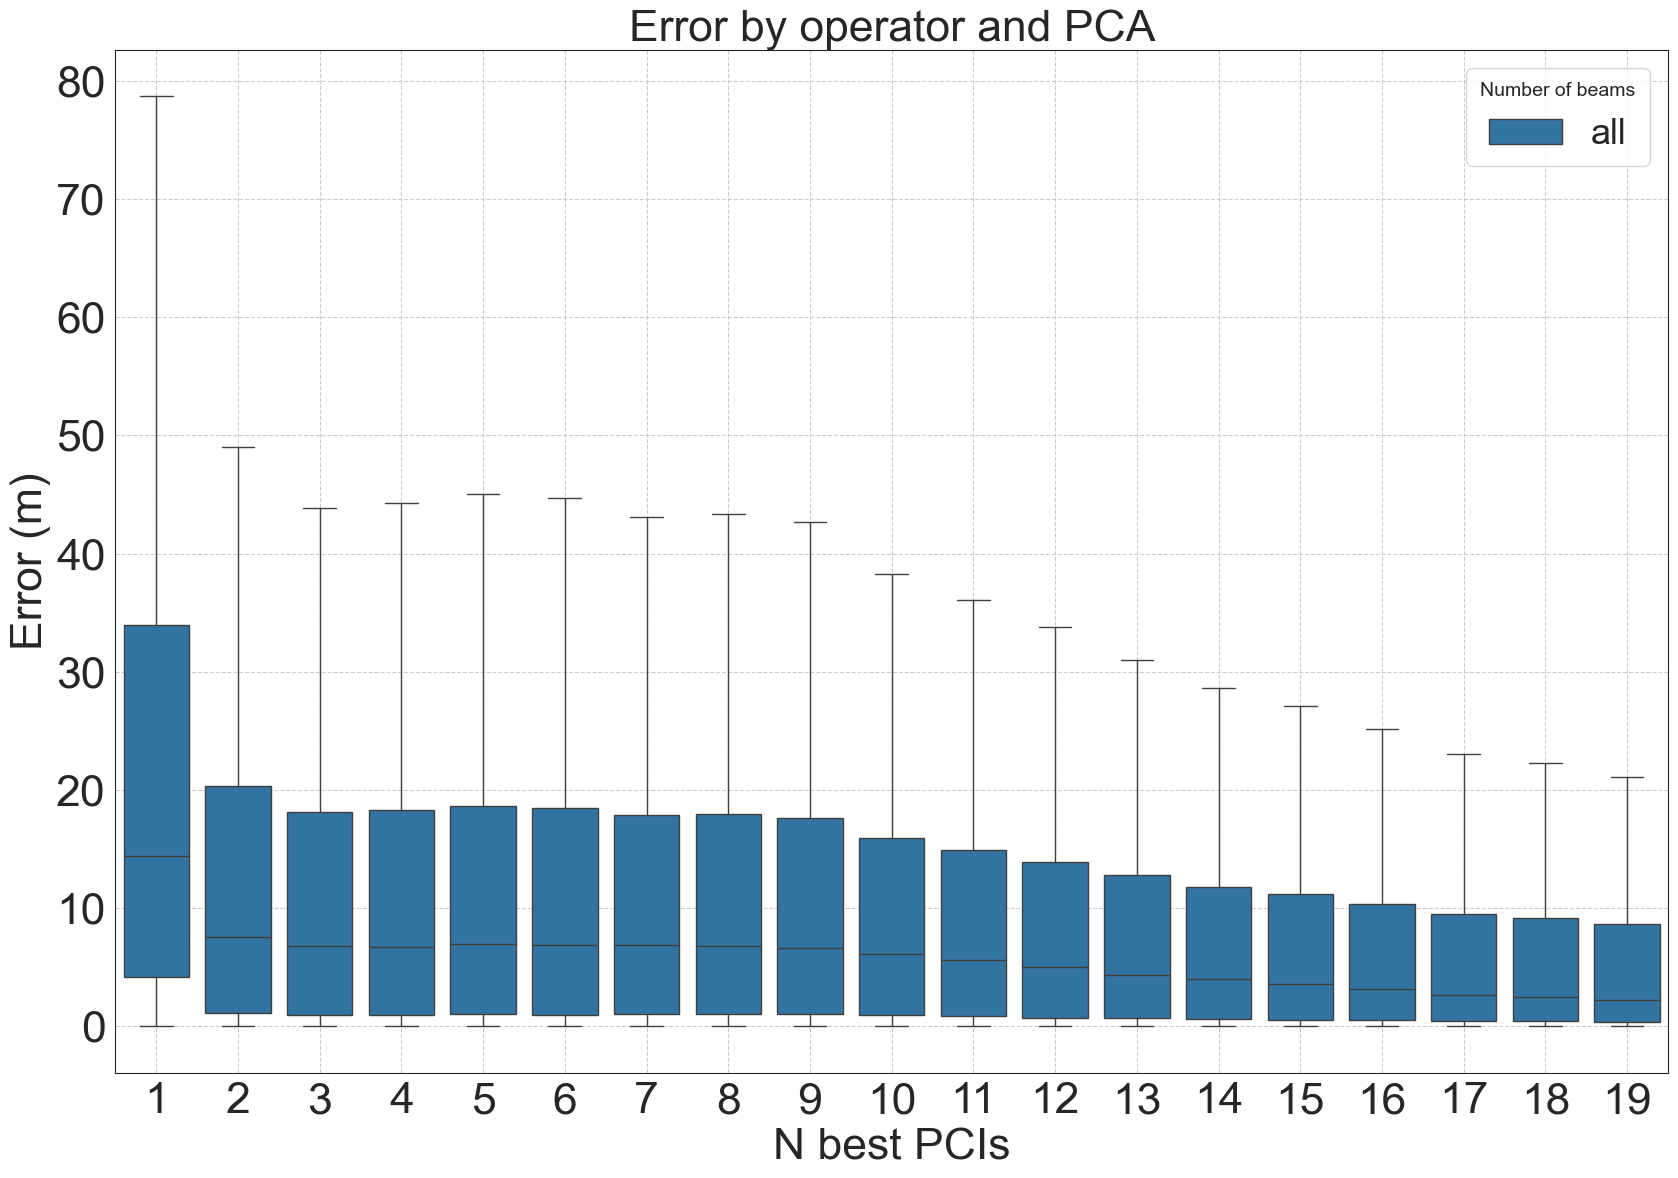

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 14})

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='n_best_pcis',
        y='errors',
        hue='n_best_beams',
        showfliers=False,
    )

    # Add labels and title
    plt.xlabel('N best PCIs')
    plt.ylabel('Error (m)')
    plt.title('Error by operator and PCA')

    plt.legend(title='Number of beams', loc='upper right')
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot(df[df['n_best_pcis'] == 9])
#plot(data_df[data_df['n_best_pcis'] >= 5])
#plot(data_df[data_df['n_best_pcis'] < 5])
plot(data_df)